In [1]:
!pip install networkx python-louvain

 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.6/204.6 kB 4.5 MB/s eta 0:00:00a 0:00:01
  Preparing metadata (setup.py) ... done
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9460 sha256=82b86934f7e128ec7e639e156975a1e660fb055dad978f4b369fe6f1324b2ca9
  Stored in directory: /home/marcelly/.cache/pip/wheels/40/f1/e3/485b698c520fa0baee1d07897abc7b8d6479b7d199ce96f4af
Successfully built python-louvain


In [2]:
#Loading dataset and mapping attributes into binary
import pandas as pd
import numpy as np

df = pd.read_csv("SelectedClean_nhis2023.csv")

df['ANXEV_A'] = df['ANXEV_A'].map({'Yes': 1, 'No': 0}).astype(int)
df['SEX_A'] = df['SEX_A'].map({'Male': 0, 'Female': 1}).astype(int)
df['HISPALLP_BIN'] = df['HISPALLP_A'].map({
    'Non-Hispanic White only': 1,  
    'Hispanic': 0,
    'Non-Hispanic Black/African American only': 0,
    'Non-Hispanic Asian only': 0,
    'Non-Hispanic AIAN only': 0,
    'Non-Hispanic AIAN and any other group': 0,
    'Multiple races': 0
}).astype(int)

df_aif = df.copy()


In [3]:
#Building k-NN graph

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import networkx as nx

target_col = "ANXEV_A"
prot_cols = ["SEX_A","HISPALLP_BIN"]  # adapt to your columns

feature_cols = [c for c in df_aif.columns
                if c not in [target_col] + prot_cols and pd.api.types.is_numeric_dtype(df_aif[c])]

X = df_aif[feature_cols].fillna(0).copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# k-NN graph (mutual or symmetric)
k = 10
nbrs = NearestNeighbors(n_neighbors=k+1, metric="euclidean").fit(X_scaled)
dist, idx = nbrs.kneighbors(X_scaled)

# build undirected similarity graph with weights ~ exp(-distance)
G = nx.Graph()
G.add_nodes_from(range(len(df_aif)))  # nodes are index positions

sigma = dist[:,1:].mean()  # scale for weight
for i in range(len(df_aif)):
    for j_pos, d in zip(idx[i,1:], dist[i,1:]):  # skip self at [:,0]
        w = np.exp(-d / (sigma + 1e-8))
        u, v = int(i), int(j_pos)
        if G.has_edge(u,v):
            # keep max weight for symmetric kNN
            G[u][v]["weight"] = max(G[u][v]["weight"], w)
        else:
            G.add_edge(u, v, weight=w)


In [4]:
#Inspecting the graph
print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())
print("Average degree:", sum(dict(G.degree()).values())/G.number_of_nodes())

Number of nodes: 29460
Number of edges: 291485
Average degree: 19.788526816021726


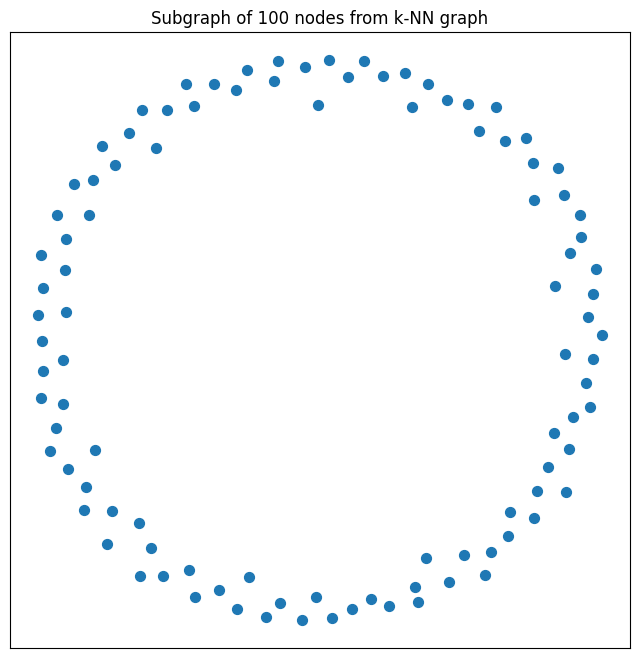

In [5]:
#Visualizing Subgraph for representation
import matplotlib.pyplot as plt
import random

# sample 100 nodes to avoid clutter
sample_nodes = random.sample(list(G.nodes()), 100)
H = G.subgraph(sample_nodes)

plt.figure(figsize=(8,8))
nx.draw_networkx(H, node_size=50, edge_color="gray", with_labels=False)
plt.title("Subgraph of 100 nodes from k-NN graph")
plt.show()

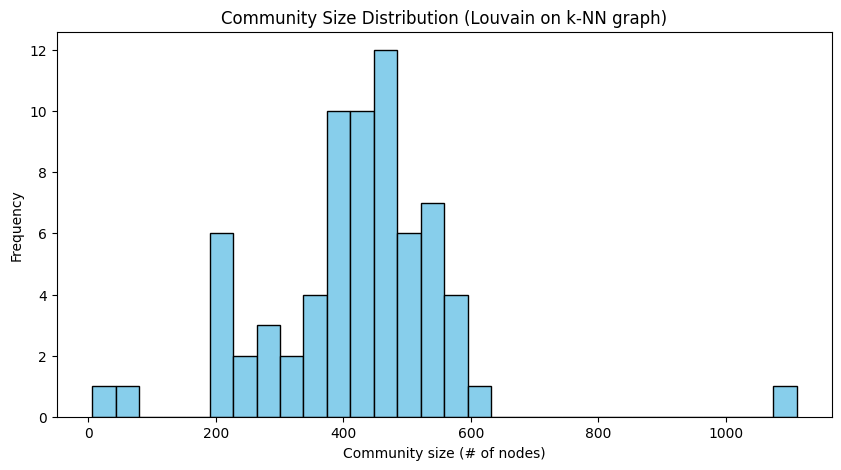

Number of communities: 70
Smallest community size: 6
Largest community size: 1111


In [25]:
#Community detection with Louvain
import matplotlib.pyplot as plt
import community as community_louvain 

# Detect communities with Louvain
partition = community_louvain.best_partition(G, weight="weight")

# Convert to DataFrame
import pandas as pd
df_comms = pd.DataFrame({"node": list(partition.keys()),
                         "community": list(partition.values())})

partition_before = partition

# Count sizes
comm_sizes = df_comms["community"].value_counts().sort_values(ascending=False)

# Plot histogram of sizes
plt.figure(figsize=(10,5))
plt.hist(comm_sizes, bins=30, color="skyblue", edgecolor="black")
plt.title("Community Size Distribution (Louvain on k-NN graph)")
plt.xlabel("Community size (# of nodes)")
plt.ylabel("Frequency")
plt.show()

# Quick stats
print("Number of communities:", comm_sizes.shape[0])
print("Smallest community size:", comm_sizes.min())
print("Largest community size:", comm_sizes.max())

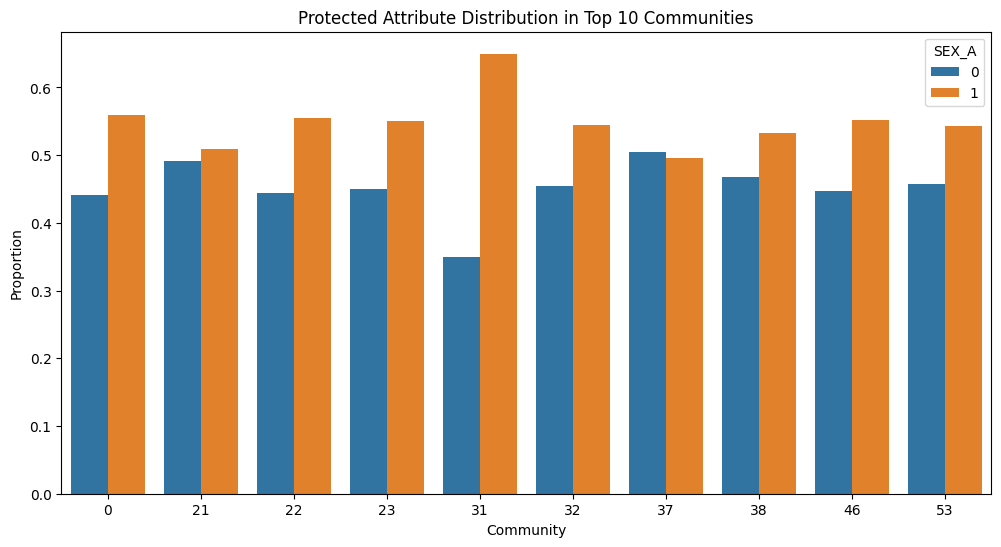

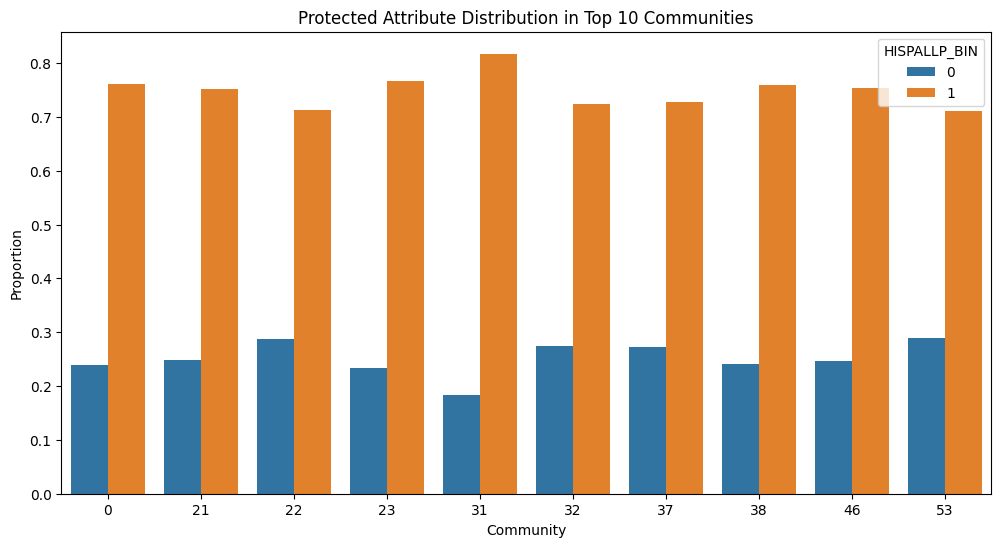

In [13]:
#Visualizing Protected Attributes Proportions after
import seaborn as sns

def plot_group_distribution(df_nodes, partition, prot_col, top_n=10):
    # Build DataFrame of node → community
    df_comms = pd.DataFrame({
        "node": list(partition.keys()),
        "community": list(partition.values())
    })
    
    # Attach protected attribute
    df_nodes = df_nodes.reset_index().rename(columns={"index": "node"})
    df_merged = df_comms.merge(df_nodes[["node", prot_col]], on="node")
    
    # Count group proportions
    comm_sizes = df_merged["community"].value_counts().head(top_n).index
    df_top = df_merged[df_merged["community"].isin(comm_sizes)]
    
    counts = (
        df_top.groupby(["community", prot_col])
        .size()
        .reset_index(name="count")
    )
    totals = counts.groupby("community")["count"].transform("sum")
    counts["proportion"] = counts["count"] / totals
    
    # Plot stacked bar
    plt.figure(figsize=(12,6))
    sns.barplot(data=counts, x="community", y="proportion", hue=prot_col)
    plt.title(f"Protected Attribute Distribution in Top {top_n} Communities")
    plt.ylabel("Proportion")
    plt.xlabel("Community")
    plt.legend(title=prot_col)
    plt.show()

# Example usage
plot_group_distribution(df_aif, partition, prot_col="SEX_A", top_n=10)
plot_group_distribution(df_aif, partition, prot_col="HISPALLP_BIN", top_n=10)


In [14]:
#Applying CLAN
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, jaccard_score

# mark small vs large communities by size threshold (tune min_size)
min_size = 30
sizes = df_comms["community"].value_counts()
large_communities = set(sizes[sizes >= min_size].index)

df_comms["is_large"] = df_comms["community"].isin(large_communities)

# Training data = nodes in large communities
train_nodes = df_comms[df_comms["is_large"]]["node"].values
y_train = df_comms.set_index("node").loc[train_nodes, "community"].values
X_train = X_scaled[train_nodes]

# Test data = nodes in small communities
test_nodes = df_comms[~df_comms["is_large"]]["node"].values
X_test  = X_scaled[test_nodes]

# Simple multinomial LR for community membership
clf = LogisticRegression(max_iter=1000, multi_class="multinomial")
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

# Reassign small-community nodes to predicted large communities
df_comms_clan = df_comms.copy()
df_comms_clan.loc[df_comms_clan["node"].isin(test_nodes), "community"] = y_pred
df_comms_clan.drop(columns="is_large", inplace=True)



/Msc_Applied_Project/MscProject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [26]:
#Dictionary for visualizing
partition_after = dict(zip(df_comms_clan["node"], df_comms_clan["community"]))



In [28]:
# How many nodes were reassigned?
changed = (df_comms["community"] != df_comms_clan["community"]).sum()
print("Number of nodes reassigned by CLAN:", changed)

Number of nodes reassigned by CLAN: 3469


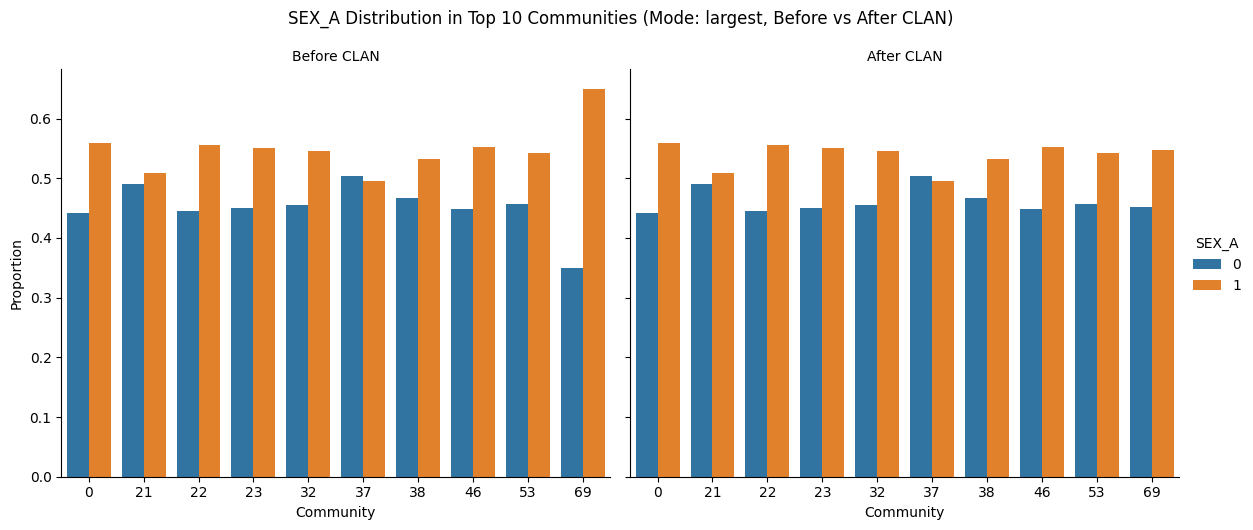

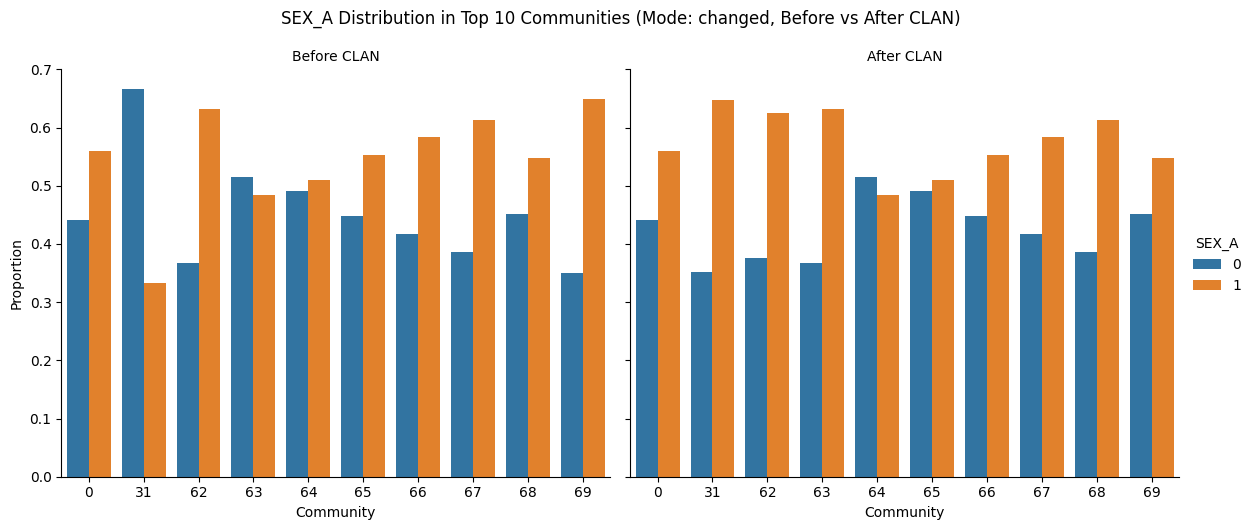

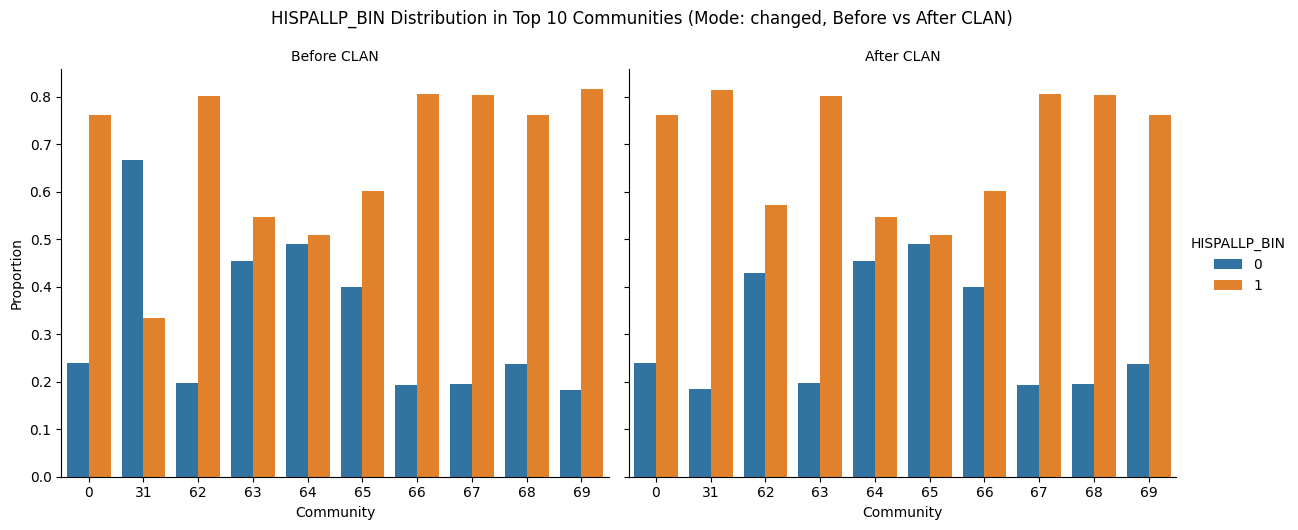

In [29]:
#Visualizing Protected Attributes Proportions after CLAN

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_group_distribution_compare(df_nodes, partition_before, partition_after, prot_col, 
                                    top_n=10, mode="largest"):
    def prepare_df(partition, df_nodes, prot_col, label):
        df_comms = pd.DataFrame({
            "node": list(partition.keys()),
            "community": list(partition.values())
        })
        df_nodes = df_nodes.reset_index().rename(columns={"index": "node"})
        df_merged = df_comms.merge(df_nodes[["node", prot_col]], on="node")

        return df_merged

    # Prepare both before and after datasets
    df_before = prepare_df(partition_before, df_nodes, prot_col, "Before CLAN")
    df_after  = prepare_df(partition_after, df_nodes, prot_col, "After CLAN")

    # Decide which communities to plot
    if mode == "largest":
        comm_sizes = df_before["community"].value_counts().head(top_n).index
    elif mode == "changed":
        # Count community sizes before/after
        size_before = df_before["community"].value_counts()
        size_after  = df_after["community"].value_counts()
        diffs = (size_after - size_before).abs().sort_values(ascending=False)
        comm_sizes = diffs.head(top_n).index
    else:
        raise ValueError("mode must be 'largest' or 'changed'")

    # Filter to selected communities
    df_before = df_before[df_before["community"].isin(comm_sizes)]
    df_after  = df_after[df_after["community"].isin(comm_sizes)]

    # Count proportions
    def get_props(df, label):
        counts = (df.groupby(["community", prot_col])
                    .size()
                    .reset_index(name="count"))
        totals = counts.groupby("community")["count"].transform("sum")
        counts["proportion"] = counts["count"] / totals
        counts["community"] = counts["community"].astype(str)
        counts["stage"] = label
        return counts

    df_before_props = get_props(df_before, "Before CLAN")
    df_after_props  = get_props(df_after,  "After CLAN")

    df_all = pd.concat([df_before_props, df_after_props])

    # Plot side-by-side
    g = sns.catplot(
        data=df_all, kind="bar",
        x="community", y="proportion", hue=prot_col,
        col="stage", sharey=True, col_wrap=2,
        height=5, aspect=1.2
    )
    g.set_axis_labels("Community", "Proportion")
    g.set_titles("{col_name}")
    g._legend.set_title(prot_col)
    plt.suptitle(
        f"{prot_col} Distribution in Top {top_n} Communities "
        f"(Mode: {mode}, Before vs After CLAN)", 
        y=1.05
    )
    plt.show()


# Compare top-10 largest communities (like before)
plot_group_distribution_compare(df_aif, partition_before, partition_after, 
                                prot_col="SEX_A", top_n=10, mode="largest")

# Compare top-10 most affected communities
plot_group_distribution_compare(df_aif, partition_before, partition_after, 
                                prot_col="SEX_A", top_n=10, mode="changed")

# Same for HISPALLP_BIN
plot_group_distribution_compare(df_aif, partition_before, partition_after, 
                                prot_col="HISPALLP_BIN", top_n=10, mode="changed")

    


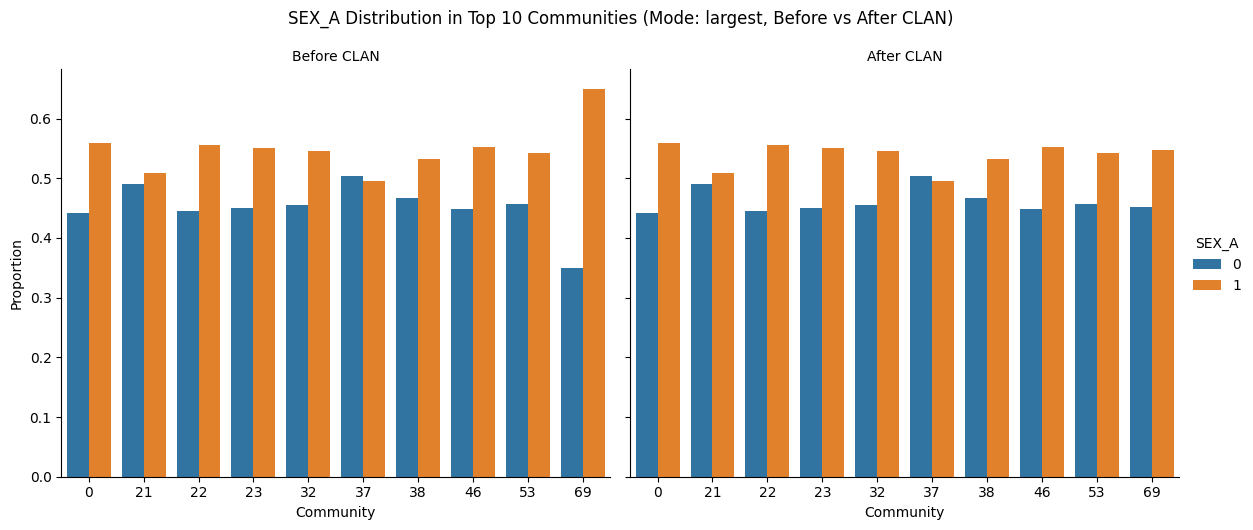


📊 Top communities most affected by CLAN:
           size_before  size_after  difference
community                                     
31                   6      1117.0      1111.0
69                1111       345.0      -766.0
65                 471       206.0      -265.0
67                 225       446.0       221.0
64                 206       386.0       180.0
62                 223        56.0      -167.0
63                 386       223.0      -163.0
68                 345       225.0      -120.0
66                 446       471.0        25.0
0                  612       612.0         0.0


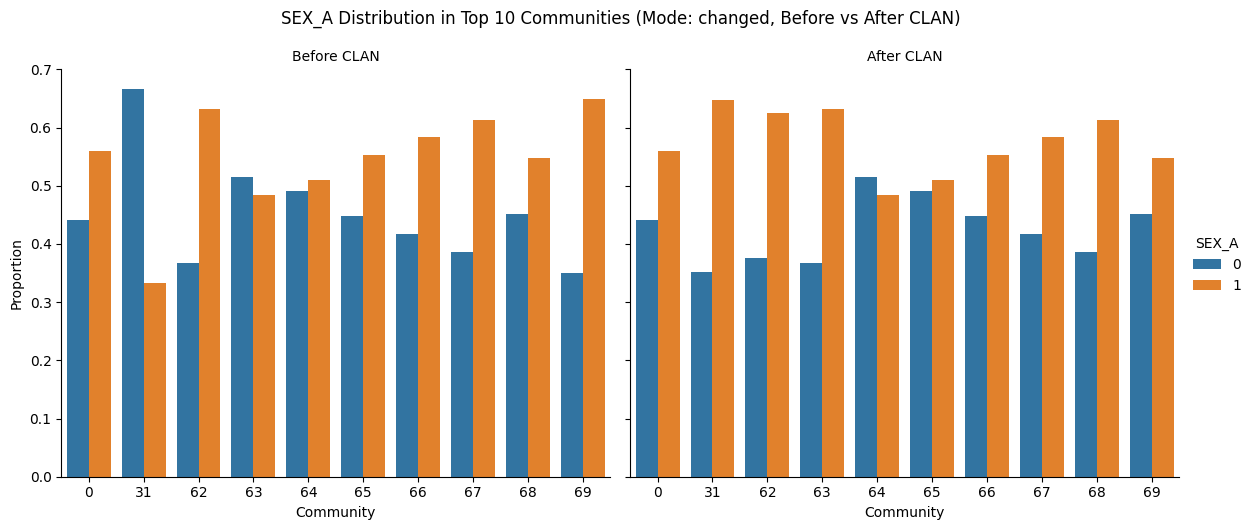


📊 Top communities most affected by CLAN:
           size_before  size_after  difference
community                                     
31                   6      1117.0      1111.0
69                1111       345.0      -766.0
65                 471       206.0      -265.0
67                 225       446.0       221.0
64                 206       386.0       180.0
62                 223        56.0      -167.0
63                 386       223.0      -163.0
68                 345       225.0      -120.0
66                 446       471.0        25.0
0                  612       612.0         0.0


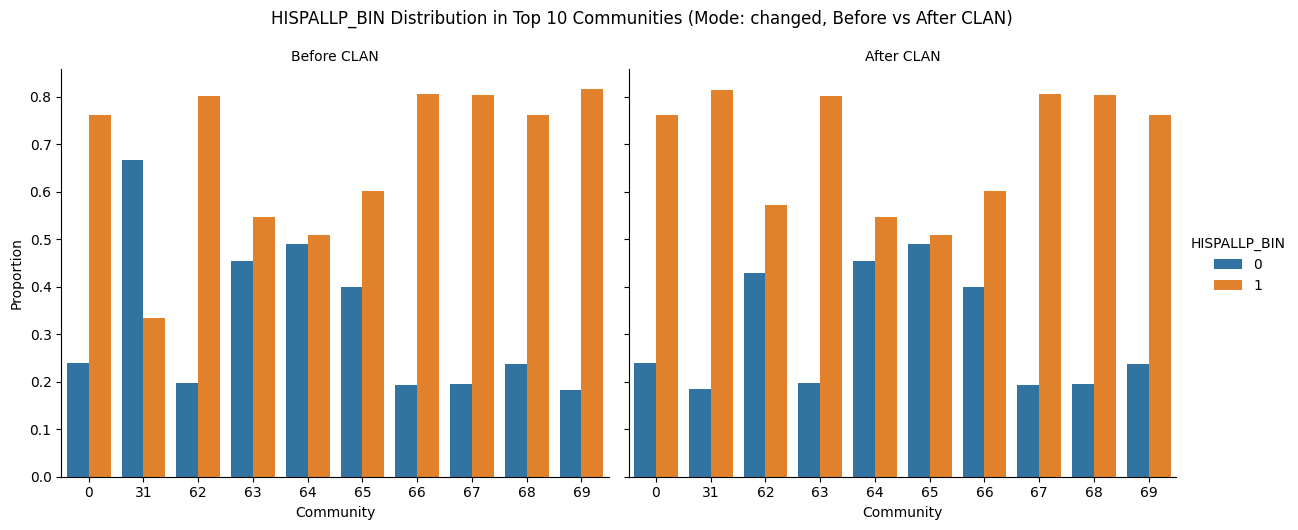

In [30]:
#Visualizing Protected Attributes Proportions after CLAN in mode change
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_group_distribution_compare(df_nodes, partition_before, partition_after, prot_col, 
                                    top_n=10, mode="largest"):
    
    def prepare_df(partition, df_nodes, prot_col, label):
        df_comms = pd.DataFrame({
            "node": list(partition.keys()),
            "community": list(partition.values())
        })
        df_nodes = df_nodes.reset_index().rename(columns={"index": "node"})
        df_merged = df_comms.merge(df_nodes[["node", prot_col]], on="node")
        return df_merged

    # Prepare both before and after datasets
    df_before = prepare_df(partition_before, df_nodes, prot_col, "Before CLAN")
    df_after  = prepare_df(partition_after, df_nodes, prot_col, "After CLAN")

    # Decide which communities to plot
    if mode == "largest":
        comm_sizes = df_before["community"].value_counts().head(top_n).index

    elif mode == "changed":
        # Count community sizes before/after
        size_before = df_before["community"].value_counts()
        size_after  = df_after["community"].value_counts()
        diffs = (size_after - size_before).sort_values(key=abs, ascending=False)

        # Show summary of top changed communities
        summary = pd.DataFrame({
            "size_before": size_before,
            "size_after": size_after,
            "difference": size_after - size_before
        }).loc[diffs.head(top_n).index]

        print("\n📊 Top communities most affected by CLAN:")
        print(summary.sort_values("difference", key=abs, ascending=False))

        comm_sizes = diffs.head(top_n).index

    else:
        raise ValueError("mode must be 'largest' or 'changed'")

    # Filter to selected communities
    df_before = df_before[df_before["community"].isin(comm_sizes)]
    df_after  = df_after[df_after["community"].isin(comm_sizes)]

    # Count proportions
    def get_props(df, label):
        counts = (df.groupby(["community", prot_col])
                    .size()
                    .reset_index(name="count"))
        totals = counts.groupby("community")["count"].transform("sum")
        counts["proportion"] = counts["count"] / totals
        counts["community"] = counts["community"].astype(str)
        counts["stage"] = label
        return counts

    df_before_props = get_props(df_before, "Before CLAN")
    df_after_props  = get_props(df_after,  "After CLAN")

    df_all = pd.concat([df_before_props, df_after_props])

    # Plot side-by-side
    g = sns.catplot(
        data=df_all, kind="bar",
        x="community", y="proportion", hue=prot_col,
        col="stage", sharey=True, col_wrap=2,
        height=5, aspect=1.2
    )
    g.set_axis_labels("Community", "Proportion")
    g.set_titles("{col_name}")
    g._legend.set_title(prot_col)
    plt.suptitle(
        f"{prot_col} Distribution in Top {top_n} Communities "
        f"(Mode: {mode}, Before vs After CLAN)", 
        y=1.05
    )
    plt.show()

# Largest communities
plot_group_distribution_compare(df_aif, partition_before, partition_after, 
                                prot_col="SEX_A", top_n=10, mode="largest")

# Most affected communities (with summary table printed)
plot_group_distribution_compare(df_aif, partition_before, partition_after, 
                                prot_col="SEX_A", top_n=10, mode="changed")

plot_group_distribution_compare(df_aif, partition_before, partition_after, 
                                prot_col="HISPALLP_BIN", top_n=10, mode="changed")




In [36]:
# Bias Diagnostics (Before vs After CLAN)

import pandas as pd
import numpy as np

def run_bias_diagnostics(df, partition_before, partition_after, prot_col, privileged, unprivileged):

    def compute_metrics(partition, label):
        # Merge partition info with protected attribute
        df_tmp = df.reset_index().rename(columns={"index": "node"})
        df_tmp["community"] = df_tmp["node"].map(partition)

        # group counts
        counts = (
            df_tmp.groupby(["community", prot_col])
            .size()
            .unstack(fill_value=0)
        )

        # proportions per community
        props = counts.div(counts.sum(axis=1), axis=0)

        # mean difference = average proportion(priv) - average proportion(unpriv)
        mean_diff = props.get(privileged, pd.Series(0)).mean() - props.get(unprivileged, pd.Series(0)).mean()

        # disparate impact = ratio of average proportions (priv / unpriv)
        avg_priv = props.get(privileged, pd.Series(0)).mean()
        avg_unpriv = props.get(unprivileged, pd.Series(0)).mean()
        disp_impact = avg_priv / avg_unpriv if avg_unpriv > 0 else np.nan

        # statistical parity diff = same as mean_diff here
        spd = mean_diff

        return {
            "Mean Difference": mean_diff,
            "Disparate Impact": disp_impact,
            "Statistical Parity Diff": spd
        }

    # Compute before/after
    metrics_before = compute_metrics(partition_before, "Before CLAN")
    metrics_after  = compute_metrics(partition_after, "After CLAN")

    # Print results
    print(f"\n=== Fairness Diagnostics for {prot_col} ===")
    print("Before CLAN:")
    for k, v in metrics_before.items():
        print(f"  {k:25}: {v:.4f}")
    print("After CLAN:")
    for k, v in metrics_after.items():
        print(f"  {k:25}: {v:.4f}")


run_bias_diagnostics(df_aif, partition_before, partition_after, 
                     prot_col="SEX_A", privileged=1, unprivileged=0)

run_bias_diagnostics(df_aif, partition_before, partition_after, 
                     prot_col="HISPALLP_BIN", privileged=1, unprivileged=0)




=== Fairness Diagnostics for SEX_A ===
Before CLAN:
  Mean Difference          : 0.0800
  Disparate Impact         : 1.1739
  Statistical Parity Diff  : 0.0800
After CLAN:
  Mean Difference          : 0.0859
  Disparate Impact         : 1.1880
  Statistical Parity Diff  : 0.0859

=== Fairness Diagnostics for HISPALLP_BIN ===
Before CLAN:
  Mean Difference          : 0.2928
  Disparate Impact         : 1.8282
  Statistical Parity Diff  : 0.2928
After CLAN:
  Mean Difference          : 0.3018
  Disparate Impact         : 1.8647
  Statistical Parity Diff  : 0.3018


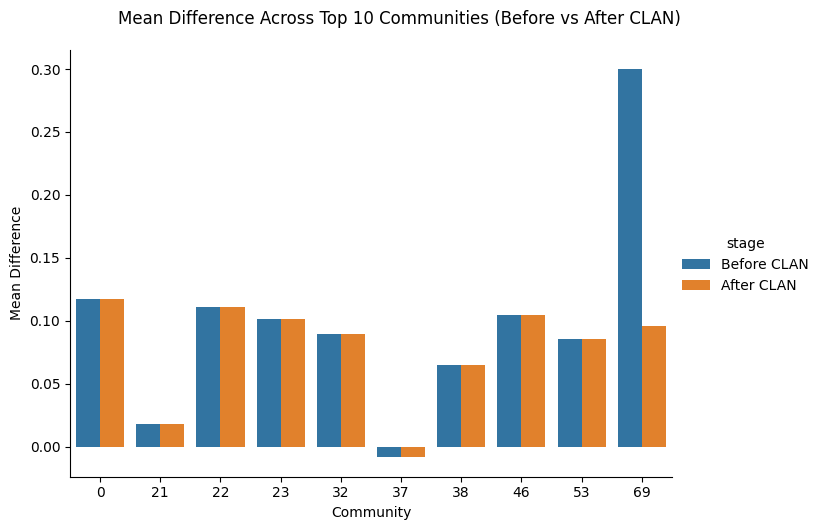

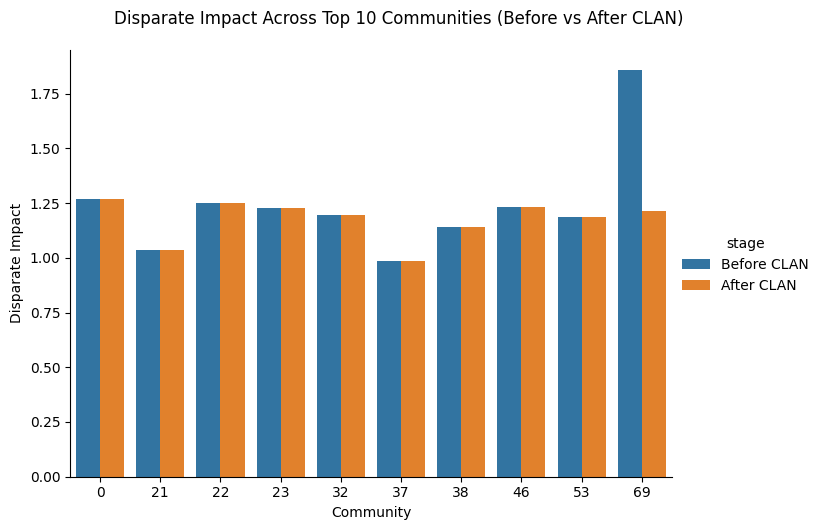

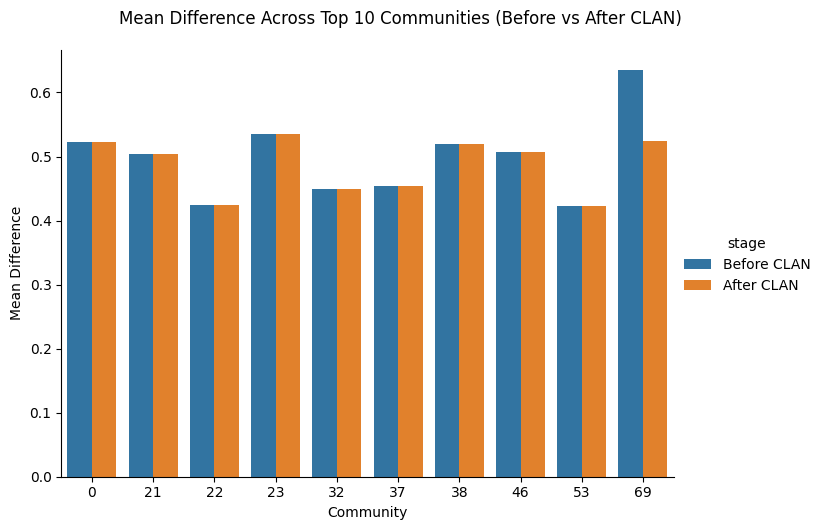

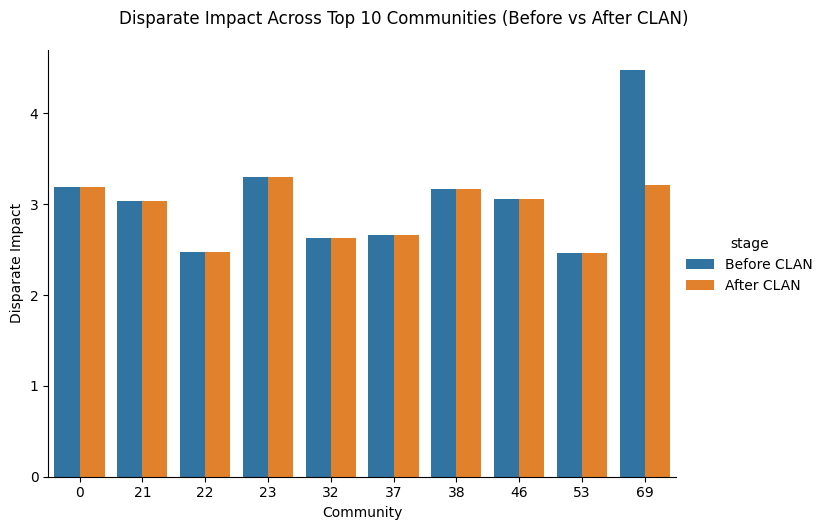

In [39]:
#Visualizing Fainerss metrics before vs after CLAN in mode change

def plot_fairness_diagnostics_compare(df, partition_before, partition_after, prot_col, privileged, unprivileged, top_n=10):


    def prepare_metrics(partition, label):
        df_tmp = df.reset_index().rename(columns={"index": "node"})
        df_tmp["community"] = df_tmp["node"].map(partition)

        # group counts
        counts = (
            df_tmp.groupby(["community", prot_col])
            .size()
            .unstack(fill_value=0)
        )

        props = counts.div(counts.sum(axis=1), axis=0)

        comm_metrics = []
        for comm in props.index:
            priv_prop = props.loc[comm].get(privileged, 0)
            unpriv_prop = props.loc[comm].get(unprivileged, 0)
            mean_diff = priv_prop - unpriv_prop
            disp_impact = priv_prop / unpriv_prop if unpriv_prop > 0 else None
            comm_metrics.append((comm, mean_diff, disp_impact, label))

        return pd.DataFrame(comm_metrics, columns=["community", "Mean Difference", "Disparate Impact", "stage"])

    # prepare both datasets
    df_before = prepare_metrics(partition_before, "Before CLAN")
    df_after  = prepare_metrics(partition_after,  "After CLAN")
    df_all = pd.concat([df_before, df_after], ignore_index=True)

    # restrict to top_n largest communities
    top_comms = (
        df.reset_index().rename(columns={"index":"node"})["node"]
        .map(partition_before)
        .value_counts().head(top_n).index
    )
    df_all = df_all[df_all["community"].isin(top_comms)]
    df_all["community"] = df_all["community"].astype(str)

    # 🚑 FIX: drop duplicates to avoid reindex issue
    df_all = df_all.drop_duplicates(subset=["community", "stage"])

    # plot side-by-side for each fairness metric
    for metric in ["Mean Difference", "Disparate Impact"]:
        g = sns.catplot(
            data=df_all, kind="bar",
            x="community", y=metric, hue="stage",
            height=5, aspect=1.4
        )
        g.set_axis_labels("Community", metric)
        g.set_titles("{col_name}")
        plt.suptitle(f"{metric} Across Top {top_n} Communities (Before vs After CLAN)", y=1.05)
        plt.show()

plot_fairness_diagnostics_compare(
    df_aif, partition_before, partition_after,
    prot_col="SEX_A", privileged=1, unprivileged=0, top_n=10
)

plot_fairness_diagnostics_compare(
    df_aif, partition_before, partition_after,
    prot_col="HISPALLP_BIN", privileged=1, unprivileged=0, top_n=10
)



In [1]:
#build k-NN graph with reweighed dataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
import networkx as nx
import community as community_louvain

# ---- Load your reweighed dataset ----
df = pd.read_csv("reweighed_intersectional.csv")

# Choose feature columns (exclude metadata / protected / target / weight)
feature_cols = [c for c in df.columns if c not in
                ["row_id", "ANXEV_A", "SEX_A", "HISPALLP_BIN", "instance_weight"]]

X = df[feature_cols].values
w = df["instance_weight"].values
N = X.shape[0]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def build_weighted_knn_graph(X_scaled, w, k):
    """
    Build a weighted mutual-kNN graph using cosine distance on features,
    then set edge weight = similarity * sqrt(w_i * w_j).
    """
    # Nearest neighbors with cosine distance
    nn = NearestNeighbors(n_neighbors=k, metric="cosine", n_jobs=-1)
    nn.fit(X_scaled)
    dist, idx = nn.kneighbors(X_scaled)  # dist in [0,2] for cosine distance (here [0,1])

    # Convert distances to cosine similarity
    sim = 1.0 - dist  # cosine_similarity = 1 - cosine_distance

    # Build sparse matrix (row i connects to idx[i, j] with weight sim[i, j])
    rows = np.repeat(np.arange(X_scaled.shape[0]), k)
    cols = idx.ravel()
    data = sim.ravel()

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))

    # Make it mutual (symmetrize): keep the minimum weight on undirected edge
    A_mut = A.minimum(A.transpose())

    # Apply instance weights: weight_ij *= sqrt(w_i * w_j)
    sqrt_outer = np.sqrt(np.outer(w, w))
    # Efficiently scale: elementwise multiply by sparse structure
    # Convert sqrt_outer to sparse by indexing only nonzeros of A_mut
    rows, cols = A_mut.nonzero()
    scaled_data = A_mut.data * sqrt_outer[rows, cols]
    A_w = sp.csr_matrix((scaled_data, (rows, cols)), shape=A_mut.shape)

    # Build NetworkX graph
    G = nx.from_scipy_sparse_array(A_w)

    # Attach node attributes 
    for i, row in df.iterrows():
        G.nodes[i]["SEX_A"] = int(row["SEX_A"])
        G.nodes[i]["HISPALLP_BIN"] = int(row["HISPALLP_BIN"])
        G.nodes[i]["ANXEV_A"] = int(row["ANXEV_A"])
        G.nodes[i]["instance_weight"] = float(row["instance_weight"])

    return G

def evaluate_graph(G):
    # Largest connected component ratio
    if G.number_of_nodes() == 0:
        return dict(lcc_ratio=0, avg_deg=0, clustering=0, modularity=np.nan, n_comp=0)

    comps = list(nx.connected_components(G))
    lcc = max(comps, key=len)
    lcc_ratio = len(lcc) / G.number_of_nodes()

    # Average degree (undirected)
    avg_deg = np.mean([d for _, d in G.degree()]) if G.number_of_nodes() > 0 else 0

    # Average clustering 
    clustering = nx.average_clustering(G)

    # Modularity via Louvain 
    part = community_louvain.best_partition(G, weight="weight")
    # Compute modularity on the LCC for stability
    G_lcc = G.subgraph(lcc).copy()
    part_lcc = {n: part[n] for n in G_lcc.nodes()}
    modularity = community_louvain.modularity(part_lcc, G_lcc, weight="weight")

    return dict(lcc_ratio=lcc_ratio, avg_deg=avg_deg, clustering=clustering,
                modularity=modularity, n_comp=len(comps))

def sweep_k_and_recommend(X_scaled, w, k_values):
    rows = []
    graphs = {}
    for k in k_values:
        G = build_weighted_knn_graph(X_scaled, w, k)
        graphs[k] = G
        stats = evaluate_graph(G)
        stats["k"] = k
        rows.append(stats)
        print(f"k={k:>3} | LCC={stats['lcc_ratio']:.3f} | deg={stats['avg_deg']:.1f} | "
              f"clust={stats['clustering']:.3f} | modularity={stats['modularity']:.3f} | comps={stats['n_comp']}")

    df_k = pd.DataFrame(rows).sort_values("k")

    # Heuristic recommendation: smallest k with LCC>=0.95 and avg_deg between 5 and 50
    candidates = df_k[(df_k["lcc_ratio"] >= 0.95) & (df_k["avg_deg"].between(5, 50))]
    if len(candidates):
        k_rec = int(candidates.sort_values(["k"]).iloc[0]["k"])
    else:
        # fallback: k that maximizes (modularity * lcc_ratio)
        df_k["score"] = df_k["modularity"].fillna(0) * df_k["lcc_ratio"]
        k_rec = int(df_k.sort_values("score", ascending=False).iloc[0]["k"])

    return df_k, k_rec, graphs[k_rec], graphs

# Pinking sensible range based on N
if N < 1000:
    k_range = list(range(5, 21, 2))      # 5,7,9,...,19
elif N < 10000:
    k_range = list(range(10, 31, 5))     # 10,15,20,25,30
else:
    k_range = list(range(15, 51, 5))     # 15..50 step 5

df_k, k_best, G_best, graphs_all = sweep_k_and_recommend(X_scaled, w, k_range)

print("\nRecommended k:", k_best)
display(df_k)



ValueError: Found array with 0 feature(s) (shape=(29460, 0)) while a minimum of 1 is required by StandardScaler.

In [4]:
print(df.columns.tolist())

['row_id', 'SEX_A', 'HISPALLP_BIN', 'ANXEV_A', 'instance_weight']


In [ ]:
#building k-NN graph with reweighed dataset
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
import networkx as nx
import community as community_louvain

# Load dataset
df = pd.read_csv("reweighed_intersectional.csv")

# Use SEX_A and HISPALLP_BIN as features
feature_cols = ["SEX_A", "HISPALLP_BIN"]
X = df[feature_cols].values
w = df["instance_weight"].values
N = X.shape[0]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def build_weighted_knn_graph(X_scaled, w, k):
    nn = NearestNeighbors(n_neighbors=k, metric="cosine", n_jobs=-1)
    nn.fit(X_scaled)
    dist, idx = nn.kneighbors(X_scaled)

    sim = 1.0 - dist

    rows = np.repeat(np.arange(N), k)
    cols = idx.ravel()
    data = sim.ravel()

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A_mut = A.minimum(A.transpose())

    sqrt_outer = np.sqrt(np.outer(w, w))
    rows_idx, cols_idx = A_mut.nonzero()
    scaled_data = A_mut.data * sqrt_outer[rows_idx, cols_idx]
    A_w = sp.csr_matrix((scaled_data, (rows_idx, cols_idx)), shape=A_mut.shape)

    G = nx.from_scipy_sparse_array(A_w)

    for i, row in df.iterrows():
        G.nodes[i]["SEX_A"] = int(row["SEX_A"])
        G.nodes[i]["HISPALLP_BIN"] = int(row["HISPALLP_BIN"])
        G.nodes[i]["ANXEV_A"] = int(row["ANXEV_A"])
        G.nodes[i]["instance_weight"] = float(row["instance_weight"])

    return G

def evaluate_graph(G):
    if G.number_of_nodes() == 0:
        return dict(lcc_ratio=0, avg_deg=0, clustering=0, modularity=np.nan, n_comp=0)

    comps = list(nx.connected_components(G))
    lcc = max(comps, key=len)
    lcc_ratio = len(lcc) / G.number_of_nodes()
    avg_deg = np.mean([d for _, d in G.degree()]) if G.number_of_nodes() > 0 else 0
    clustering = nx.average_clustering(G)
    part = community_louvain.best_partition(G, weight="weight")
    G_lcc = G.subgraph(lcc).copy()
    part_lcc = {n: part[n] for n in G_lcc.nodes()}
    modularity = community_louvain.modularity(part_lcc, G_lcc, weight="weight")

    return dict(lcc_ratio=lcc_ratio, avg_deg=avg_deg, clustering=clustering,
                modularity=modularity, n_comp=len(comps))

def sweep_k_and_recommend(X_scaled, w, k_values):
    rows = []
    graphs = {}
    for k in k_values:
        G = build_weighted_knn_graph(X_scaled, w, k)
        graphs[k] = G
        stats = evaluate_graph(G)
        stats["k"] = k
        rows.append(stats)
        print(f"k={k:>3} | LCC={stats['lcc_ratio']:.3f} | deg={stats['avg_deg']:.1f} | "
              f"clust={stats['clustering']:.3f} | modularity={stats['modularity']:.3f} | comps={stats['n_comp']}")

    df_k = pd.DataFrame(rows).sort_values("k")
    candidates = df_k[(df_k["lcc_ratio"] >= 0.95) & (df_k["avg_deg"].between(5, 50))]
    if len(candidates):
        k_rec = int(candidates.sort_values(["k"]).iloc[0]["k"])
    else:
        df_k["score"] = df_k["modularity"].fillna(0) * df_k["lcc_ratio"]
        k_rec = int(df_k.sort_values("score", ascending=False).iloc[0]["k"])

    return df_k, k_rec, graphs[k_rec], graphs

# Choose k range
if N < 1000:
    k_range = list(range(5, 21, 2))
elif N < 10000:
    k_range = list(range(10, 31, 5))
else:
    k_range = list(range(15, 51, 5))

df_k, k_best, G_best, graphs_all = sweep_k_and_recommend(X_scaled, w, k_range)

print("\nRecommended k:", k_best)
display(df_k)


In [5]:
#Checking for best k but with memory usage optimized

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import scipy.sparse as sp
import networkx as nx
import community as community_louvain

# Load dataset
df = pd.read_csv("reweighed_intersectional.csv")

# Features (SEX_A and HISPALLP_BIN)
feature_cols = ["SEX_A", "HISPALLP_BIN"]
X = df[feature_cols].values.astype(np.float32)
w = df["instance_weight"].values.astype(np.float32)
N = X.shape[0]

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X).astype(np.float32)

# Memory-efficient k-NN graph builder
def build_weighted_knn_graph(X_scaled, w, k):
    N = X_scaled.shape[0]

    # Nearest neighbors with cosine distance
    nn = NearestNeighbors(n_neighbors=k, metric="cosine", n_jobs=-1)
    nn.fit(X_scaled)
    dist, idx = nn.kneighbors(X_scaled)

    sim = 1.0 - dist  # cosine similarity

    rows = np.repeat(np.arange(N), k)
    cols = idx.ravel()
    data = sim.ravel().astype(np.float32)

    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))
    A_mut = A.minimum(A.transpose())  # mutual kNN

    # Apply instance weights only to nonzero edges
    rows_idx, cols_idx = A_mut.nonzero()
    scaled_data = A_mut.data * np.sqrt(w[rows_idx] * w[cols_idx])
    A_w = sp.csr_matrix((scaled_data, (rows_idx, cols_idx)), shape=A_mut.shape)

    # Build NetworkX graph
    G = nx.from_scipy_sparse_array(A_w)

    # Attach node attributes
    for i, row in df.iterrows():
        G.nodes[i]["SEX_A"] = int(row["SEX_A"])
        G.nodes[i]["HISPALLP_BIN"] = int(row["HISPALLP_BIN"])
        G.nodes[i]["ANXEV_A"] = int(row["ANXEV_A"])
        G.nodes[i]["instance_weight"] = float(row["instance_weight"])

    return G

# Graph evaluation 
def evaluate_graph(G):
    if G.number_of_nodes() == 0:
        return dict(lcc_ratio=0, avg_deg=0, clustering=0, modularity=np.nan, n_comp=0)

    comps = list(nx.connected_components(G))
    lcc = max(comps, key=len)
    lcc_ratio = len(lcc) / G.number_of_nodes()
    avg_deg = np.mean([d for _, d in G.degree()])
    clustering = nx.average_clustering(G)
    part = community_louvain.best_partition(G, weight="weight")
    G_lcc = G.subgraph(lcc).copy()
    part_lcc = {n: part[n] for n in G_lcc.nodes()}
    modularity = community_louvain.modularity(part_lcc, G_lcc, weight="weight")

    return dict(lcc_ratio=lcc_ratio, avg_deg=avg_deg, clustering=clustering,
                modularity=modularity, n_comp=len(comps))

# Sweep k and recommend 
def sweep_k_and_recommend(X_scaled, w, k_values):
    rows = []
    graphs = {}
    for k in k_values:
        G = build_weighted_knn_graph(X_scaled, w, k)
        graphs[k] = G
        stats = evaluate_graph(G)
        stats["k"] = k
        rows.append(stats)
        print(f"k={k:>3} | LCC={stats['lcc_ratio']:.3f} | deg={stats['avg_deg']:.1f} | "
              f"clust={stats['clustering']:.3f} | modularity={stats['modularity']:.3f} | comps={stats['n_comp']}")

    df_k = pd.DataFrame(rows).sort_values("k")
    candidates = df_k[(df_k["lcc_ratio"] >= 0.95) & (df_k["avg_deg"].between(5, 50))]
    if len(candidates):
        k_rec = int(candidates.sort_values(["k"]).iloc[0]["k"])
    else:
        df_k["score"] = df_k["modularity"].fillna(0) * df_k["lcc_ratio"]
        k_rec = int(df_k.sort_values("score", ascending=False).iloc[0]["k"])

    return df_k, k_rec, graphs[k_rec], graphs

# Choose sensible k range 
if N < 1000:
    k_range = list(range(5, 21, 2))
elif N < 10000:
    k_range = list(range(10, 31, 5))
else:
    k_range = list(range(5, 21, 2))  # smaller k for memory safety

# --- Run sweep ---
df_k, k_best, G_best, graphs_all = sweep_k_and_recommend(X_scaled, w, k_range)

print("\nRecommended k:", k_best)
display(df_k)



k=  5 | LCC=0.000 | deg=0.0 | clust=0.001 | modularity=0.000 | comps=29444
k=  7 | LCC=0.000 | deg=0.0 | clust=0.001 | modularity=0.000 | comps=29436
k=  9 | LCC=0.000 | deg=0.0 | clust=0.001 | modularity=0.000 | comps=29428
k= 11 | LCC=0.000 | deg=0.0 | clust=0.001 | modularity=0.000 | comps=29420
k= 13 | LCC=0.000 | deg=0.0 | clust=0.002 | modularity=0.000 | comps=29412
k= 15 | LCC=0.001 | deg=0.0 | clust=0.002 | modularity=0.000 | comps=29404
k= 17 | LCC=0.001 | deg=0.0 | clust=0.002 | modularity=0.000 | comps=29396
k= 19 | LCC=0.001 | deg=0.1 | clust=0.003 | modularity=0.000 | comps=29388

Recommended k: 5


,lcc_ratio,avg_deg,clustering,modularity,n_comp,k,score
0,0.000170,0.004073,0.000679,0.0,29444,5,0.0
1,0.000238,0.007604,0.000950,0.0,29436,7,0.0
2,0.000305,0.012220,0.001222,0.0,29428,9,0.0
3,0.000373,0.017923,0.001494,0.0,29420,11,0.0
4,0.000441,0.024711,0.001765,0.0,29412,13,0.0
5,0.000509,0.032587,0.002037,0.0,29404,15,0.0
6,0.000577,0.041548,0.002308,0.0,29396,17,0.0
7,0.000645,0.051595,0.002580,0.0,29388,19,0.0


In [6]:
#Building k-NN graph with the best k
def build_weighted_knn_graph_with_k(X_scaled, w, k):

    import numpy as np
    import scipy.sparse as sp
    import networkx as nx
    import pandas as pd

    N = X_scaled.shape[0]

    # Nearest neighbors with cosine distance
    from sklearn.neighbors import NearestNeighbors
    nn = NearestNeighbors(n_neighbors=k, metric="cosine", n_jobs=-1)
    nn.fit(X_scaled)
    dist, idx = nn.kneighbors(X_scaled)

    # Convert distances to cosine similarity
    sim = 1.0 - dist  # cosine_similarity = 1 - cosine_distance

    # Build sparse adjacency matrix
    rows = np.repeat(np.arange(N), k)
    cols = idx.ravel()
    data = sim.ravel().astype(np.float32)
    A = sp.csr_matrix((data, (rows, cols)), shape=(N, N))

    # Make mutual (minimum weight for undirected edge)
    A_mut = A.minimum(A.transpose())

    # Apply instance weights only on nonzero edges
    rows_idx, cols_idx = A_mut.nonzero()
    scaled_data = A_mut.data * np.sqrt(w[rows_idx] * w[cols_idx])
    A_w = sp.csr_matrix((scaled_data, (rows_idx, cols_idx)), shape=A_mut.shape)

    # Build NetworkX graph
    G = nx.from_scipy_sparse_array(A_w)

    # Attach node attributes from dataframe 'df'
    for i, row in df.iterrows():
        G.nodes[i]["SEX_A"] = int(row["SEX_A"])
        G.nodes[i]["HISPALLP_BIN"] = int(row["HISPALLP_BIN"])
        G.nodes[i]["ANXEV_A"] = int(row["ANXEV_A"])
        G.nodes[i]["instance_weight"] = float(row["instance_weight"])

    return G


In [7]:
G_final = build_weighted_knn_graph_with_k(X_scaled, w, k_best)


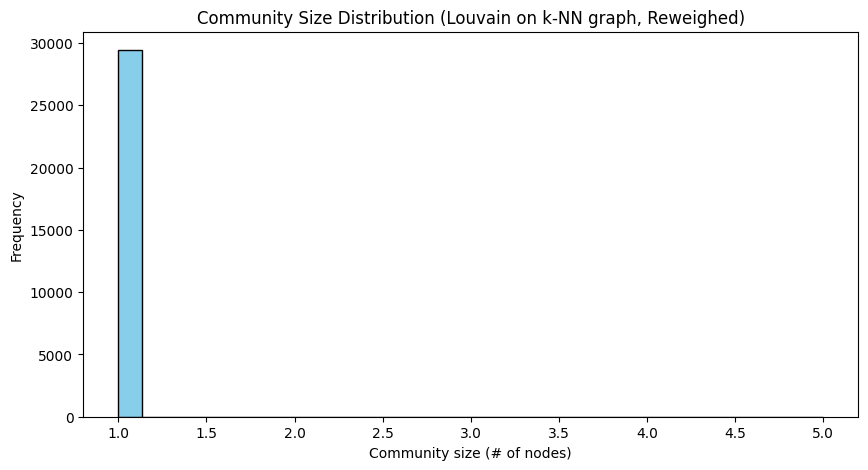

Number of communities: 29444
Smallest community size: 1
Largest community size: 5


In [8]:
#Applying Community detection in the  rewwieghed-based graph

import matplotlib.pyplot as plt
import community as community_louvain
import pandas as pd

# Run Louvain on the reweighed k-NN graph
partition_after = community_louvain.best_partition(G_final, weight="weight")

# Convert to DataFrame
df_comms_after = pd.DataFrame({
    "node": list(partition_after.keys()),
    "community": list(partition_after.values())
})

# Count community sizes
comm_sizes_after = df_comms_after["community"].value_counts().sort_values(ascending=False)

# Plot histogram
plt.figure(figsize=(10,5))
plt.hist(comm_sizes_after, bins=30, color="skyblue", edgecolor="black")
plt.title("Community Size Distribution (Louvain on k-NN graph, Reweighed)")
plt.xlabel("Community size (# of nodes)")
plt.ylabel("Frequency")
plt.show()

# Quick stats
print("Number of communities:", comm_sizes_after.shape[0])
print("Smallest community size:", comm_sizes_after.min())
print("Largest community size:", comm_sizes_after.max())


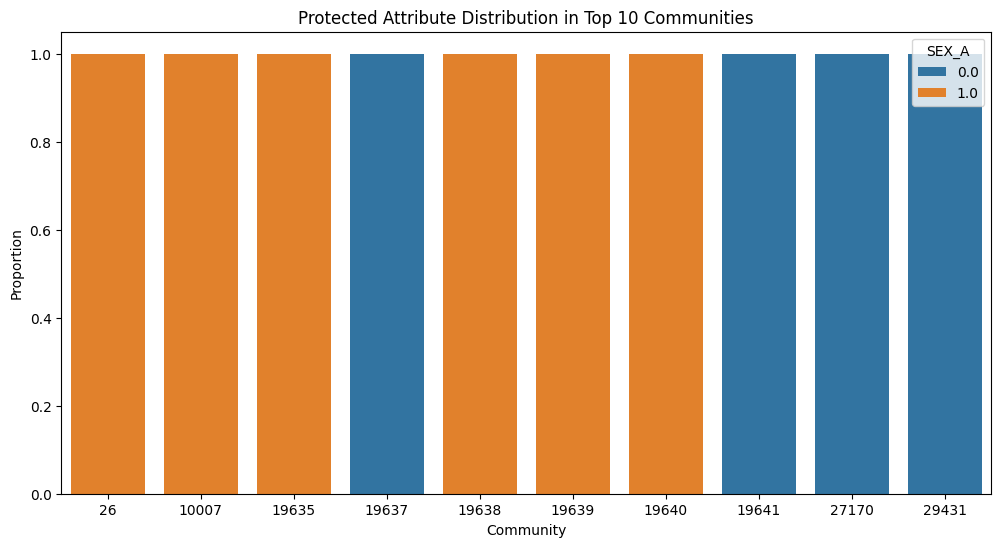

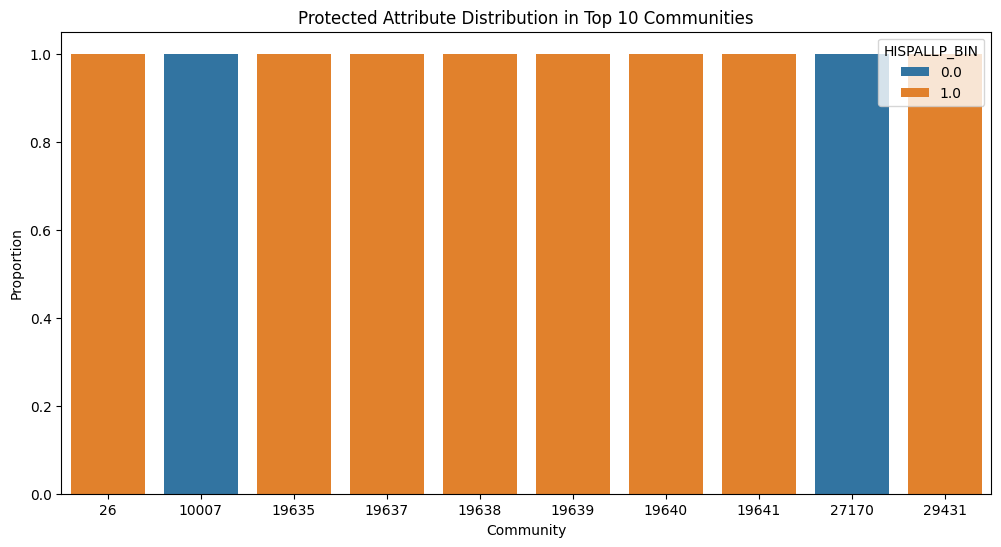

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_group_distribution(df_nodes, partition, prot_col, top_n=10):
 
    # Build DataFrame of node → community
    df_comms = pd.DataFrame({
        "node": list(partition.keys()),
        "community": list(partition.values())
    })
    
    # Attach protected attribute
    df_nodes = df_nodes.reset_index().rename(columns={"index": "node"})
    df_merged = df_comms.merge(df_nodes[["node", prot_col]], on="node")
    
    # Select top N largest communities
    comm_sizes = df_merged["community"].value_counts().head(top_n).index
    df_top = df_merged[df_merged["community"].isin(comm_sizes)]
    
    # Compute proportions
    counts = (
        df_top.groupby(["community", prot_col])
        .size()
        .reset_index(name="count")
    )
    totals = counts.groupby("community")["count"].transform("sum")
    counts["proportion"] = counts["count"] / totals
    
    # Plot stacked bar chart
    plt.figure(figsize=(12,6))
    sns.barplot(data=counts, x="community", y="proportion", hue=prot_col)
    plt.title(f"Protected Attribute Distribution in Top {top_n} Communities")
    plt.ylabel("Proportion")
    plt.xlabel("Community")
    plt.legend(title=prot_col)
    plt.show()

# --- Example usage with G_final and partition_after ---
plot_group_distribution(df, partition_after, prot_col="SEX_A", top_n=10)
plot_group_distribution(df, partition_after, prot_col="HISPALLP_BIN", top_n=10)


In [ ]:
#Applying CLAN in the reweighed dataset

from sklearn.linear_model import LogisticRegression

if "df_comms_after" not in globals():
    raise RuntimeError("You must run the Louvain community detection cell before running CLAN.")

# --- Mark large vs small communities ---
min_size = 1
sizes = df_comms_after["community"].value_counts()
large_communities = set(sizes[sizes >= min_size].index)

df_comms_after["is_large"] = df_comms_after["community"].isin(large_communities)

print("Number of large communities:", len(large_communities))

# --- Train/test split for CLAN ---
train_nodes = df_comms_after[df_comms_after["is_large"]]["node"].values
y_train = df_comms_after.set_index("node").loc[train_nodes, "community"].values
X_train = X_scaled[train_nodes]

test_nodes = df_comms_after[~df_comms_after["is_large"]]["node"].values
X_test  = X_scaled[test_nodes]

# --- Train multinomial logistic regression ---
clf = LogisticRegression(max_iter=1000, multi_class="multinomial")
clf.fit(X_train, y_train)

# --- Predict for small-community nodes ---
y_pred = clf.predict(X_test)

# --- Reassign small-community nodes ---
df_comms_clan = df_comms_after.copy()
df_comms_clan.loc[df_comms_clan["node"].isin(test_nodes), "community"] = y_pred
df_comms_clan = df_comms_clan.drop(columns="is_large")

# Convert to dictionary mapping {node: community}
partition_after_clan = dict(zip(df_comms_clan["node"], df_comms_clan["community"]))



Number of large communities: 29444


/Msc_Applied_Project/MscProject/lib/python3.12/site-packages/sklearn/utils/multiclass.py:213: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  y_type = type_of_target(y, input_name="y")
/Msc_Applied_Project/MscProject/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Total communities: 29444
Min size: 1
Max size: 5
Mean size: 1.000543404428746
Median size: 1.0


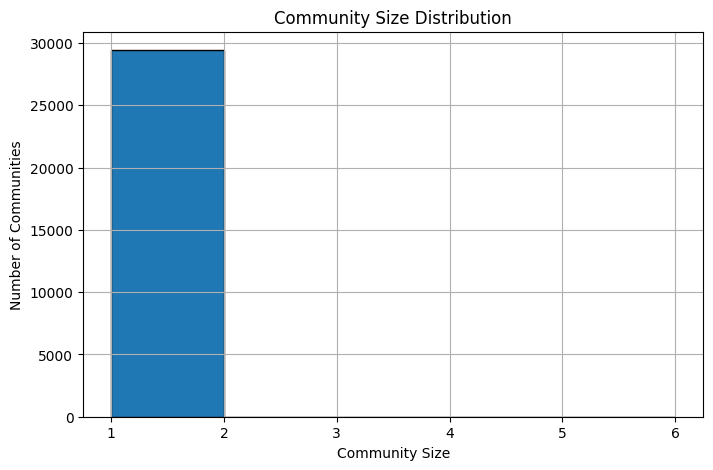

In [14]:
#Analyzing community size distribution

import matplotlib.pyplot as plt

# Count sizes of each community
sizes = df_comms_after["community"].value_counts()

# Summary stats
print("Total communities:", len(sizes))
print("Min size:", sizes.min())
print("Max size:", sizes.max())
print("Mean size:", sizes.mean())
print("Median size:", sizes.median())

# Quick histogram
plt.figure(figsize=(8, 5))
sizes.hist(bins=range(1, sizes.max()+2), edgecolor='black')
plt.xlabel("Community Size")
plt.ylabel("Number of Communities")
plt.title("Community Size Distribution")
plt.show()


   min_size  train_nodes  test_nodes   train_pct   test_pct
0         1        29460           0  100.000000   0.000000
1         2           20       29440    0.067889  99.932111
2         3           20       29440    0.067889  99.932111
3         4           20       29440    0.067889  99.932111
4         5           20       29440    0.067889  99.932111


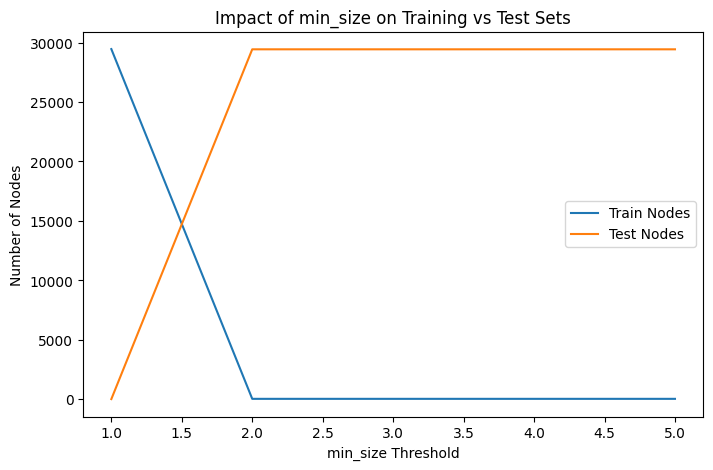

In [15]:
#Deciding which community sizes thresholds are better 
def evaluate_thresholds(df_comms_after):
    sizes = df_comms_after["community"].value_counts()
    total_nodes = len(df_comms_after)

    results = []
    for min_size in range(1, sizes.max() + 1):
        large_comms = sizes[sizes >= min_size].index
        train_nodes = df_comms_after[df_comms_after["community"].isin(large_comms)]
        test_nodes = df_comms_after[~df_comms_after["community"].isin(large_comms)]

        results.append({
            "min_size": min_size,
            "train_nodes": len(train_nodes),
            "test_nodes": len(test_nodes),
            "train_pct": len(train_nodes) / total_nodes * 100,
            "test_pct": len(test_nodes) / total_nodes * 100,
        })

    return pd.DataFrame(results)

threshold_df = evaluate_thresholds(df_comms_after)
print(threshold_df)

# Visualize training vs test nodes as min_size increases
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["min_size"], threshold_df["train_nodes"], label="Train Nodes")
plt.plot(threshold_df["min_size"], threshold_df["test_nodes"], label="Test Nodes")
plt.xlabel("min_size Threshold")
plt.ylabel("Number of Nodes")
plt.title("Impact of min_size on Training vs Test Sets")
plt.legend()
plt.show()


In [12]:
#Applying CLAN in the reweighed dataset 
#(memory efficient with random forest)

from sklearn.ensemble import RandomForestClassifier
import numpy as np
import pandas as pd

def run_clan_rf(df_comms_after, X_scaled, min_size=1, n_estimators=50):
 
    # --- Identify large vs small communities ---
    sizes = df_comms_after["community"].value_counts()
    large_communities = set(sizes[sizes >= min_size].index)
    df_comms_after = df_comms_after.copy()
    df_comms_after["is_large"] = df_comms_after["community"].isin(large_communities)

    print("Number of large communities:", len(large_communities))

    # --- Train/test split ---
    train_nodes = df_comms_after.loc[df_comms_after["is_large"], "node"].to_numpy()
    test_nodes  = df_comms_after.loc[~df_comms_after["is_large"], "node"].to_numpy()

    if len(train_nodes) == 0 or len(test_nodes) == 0:
        print("Not enough nodes to run CLAN (check min_size). Returning original partition.")
        return df_comms_after.drop(columns="is_large"), dict(zip(df_comms_after["node"], df_comms_after["community"]))

    # Labels only for training nodes
    y_train = df_comms_after.set_index("node").loc[train_nodes, "community"].to_numpy()

    # Slice X_scaled directly
    X_train = X_scaled[train_nodes, :]
    X_test  = X_scaled[test_nodes, :]

    # --- Train Random Forest ---
    clf = RandomForestClassifier(
        n_estimators=n_estimators,   # fewer trees → faster, less memory
        max_depth=None,              # allow full growth
        n_jobs=-1,                   # use all CPUs
        verbose=1                    # show progress
    )
    clf.fit(X_train, y_train)

    # --- Predict and reassign ---
    y_pred = clf.predict(X_test)

    df_comms_clan = df_comms_after.copy()
    df_comms_clan.loc[df_comms_clan["node"].isin(test_nodes), "community"] = y_pred
    df_comms_clan = df_comms_clan.drop(columns="is_large")

    partition_after_clan = dict(zip(df_comms_clan["node"], df_comms_clan["community"]))

    return df_comms_clan, partition_after_clan


df_comms_clan, partition_after_clan = run_clan_rf(df_comms_after, X_scaled, min_size=1, n_estimators=50)


Number of large communities: 29444
Not enough nodes to run CLAN (check min_size). Returning original partition.


In [1]:
#Comparing communities sizes( Before/after CLAN)

import pandas as pd
import matplotlib.pyplot as plt

def compare_sizes(partition_before, partition_after):
    # Convert to DataFrames
    df_before = pd.Series(partition_before, name="community").value_counts().reset_index()
    df_before.columns = ["community", "size_before"]

    df_after = pd.Series(partition_after, name="community").value_counts().reset_index()
    df_after.columns = ["community", "size_after"]

    # Merge by community ID (some may be reassigned, so outer join)
    df_sizes = pd.merge(df_before, df_after, on="community", how="outer").fillna(0)

    # Plot side-by-side comparison
    df_sizes.set_index("community")[["size_before", "size_after"]].plot(
        kind="bar", figsize=(12,6), alpha=0.8
    )
    plt.title("Community Sizes: Before vs After CLAN")
    plt.ylabel("Number of nodes")
    plt.xlabel("Community ID")
    plt.show()

    return df_sizes

df_size_comparison = compare_sizes(partition_before, partition_after)


NameError: name 'partition_before' is not defined